# DATASCI 503, Homework 5: Resampling Methods

Resampling methods are techniques that repeatedly draw samples from a training set and refit a model to each sample to obtain additional information about the fitted model. In this assignment, we explore two key resampling methods: **bootstrap** (for estimating the variability of an estimator) and **cross-validation** (for estimating test error and selecting models). These methods connect directly to the bias-variance tradeoff—cross-validation helps us choose models that balance underfitting and overfitting, while bootstrap helps us quantify uncertainty in our estimates.

In [3]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")

---

**Problem 1 (ISLP Ch 5, Exercise 2):** Bootstrap Sampling Probability

We will now derive the probability that a given observation is part of a bootstrap sample. Suppose that we obtain a bootstrap sample from a set of $n$ observations.

**(a)** What is the probability that the first bootstrap observation is not the $j$-th observation from the original sample? Justify your answer.

A bootstrap draw samples uniformly from the $n$ observations (with replacement), so $P(\text{draw }=j)=\frac{1}{n}$. Hence

$$
P(\text{1st bootstrap draw} \neq j)=1-\frac{1}{n}=\frac{n-1}{n}.
$$

**(b)** What is the probability that the second bootstrap observation is not the $j$-th observation from the original sample?

The second draw is generated the same way, so

$$
P(\text{2nd bootstrap draw} \neq j)=1-\frac{1}{n}=\frac{n-1}{n}.
$$

**(c)** Argue that the probability that the $j$-th observation is not in the bootstrap sample is $(1 - \frac{1}{n})^n$.

For any single draw, $P(\text{not } j)=1-\frac{1}{n}$. The $n$ draws are independent (sampling with replacement), so

$$
P(\text{observation } j \text{ is never selected in } n \text{ draws})
=\left(1-\frac{1}{n}\right)^n.
$$

**(d)** When $n = 5$, what is the probability that the $j$-th observation is in the bootstrap sample? Store your answer in a variable called `prob_in_sample_n5`. Then explain your calculation.

In [4]:
def prob_in_sample_n(n): 
    return float(1 - (1 - 1/n)**n)

n = 5
prob_in_sample_n5 = prob_in_sample_n(n)
prob_in_sample_n5

0.6723199999999999

For any single bootstrap draw, the probability of *not* selecting observation $j$ is $1-\frac{1}{n}$. Because the bootstrap sample contains $n$ independent draws (sampling with replacement),

$$
P(j \text{ not selected in the bootstrap sample})=\left(1-\frac{1}{n}\right)^n.
$$

Therefore,

$$
P(j \text{ is in the bootstrap sample})
=1-\left(1-\frac{1}{n}\right)^n.
$$

With $n=5$,

$$
P(j \text{ is in the bootstrap sample})
=1-\left(1-\frac{1}{5}\right)^5
=1-\left(\frac{4}{5}\right)^5.
$$

In [5]:
# Test assertions
assert isinstance(prob_in_sample_n5, float), "Result should be a float"
assert 0 < prob_in_sample_n5 < 1, "Probability must be between 0 and 1"
print("All tests passed!")

All tests passed!


**(e)** When $n = 100$, what is the probability that the $j$-th observation is in the bootstrap sample? Store your answer in a variable called `prob_in_sample_n100`.

In [6]:
n = 100
prob_in_sample_n100 = prob_in_sample_n(n)
prob_in_sample_n100

0.6339676587267709

In [7]:
# Test assertions
assert isinstance(prob_in_sample_n100, float), "Result should be a float"
assert 0 < prob_in_sample_n100 < 1, "Probability must be between 0 and 1"
print("All tests passed!")

All tests passed!


**(f)** When $n = 10{,}000$, what is the probability that the $j$-th observation is in the bootstrap sample? Store your answer in a variable called `prob_in_sample_n10000`.

In [8]:
n = 10_000
prob_in_sample_n10000 = prob_in_sample_n(n)
prob_in_sample_n10000

0.6321389535670295

In [9]:
# Test assertions
assert isinstance(prob_in_sample_n10000, float), "Result should be a float"
assert 0 < prob_in_sample_n10000 < 1, "Probability must be between 0 and 1"
print("All tests passed!")

All tests passed!


---

**Problem 2 (ISLP Ch 5, Exercise 4):** Estimating Standard Deviation of Predictions

Suppose that we use some statistical learning method to make a prediction for the response $Y$ for a particular value of the predictor $X$. Carefully describe how we might estimate the standard deviation of our prediction.

One way to estimate the standard deviation of a prediction at a particular predictor value $x_0$ is to use the bootstrap.

1. Fit the model on the original training data and define the prediction rule $\hat f(\cdot)$. Let the target prediction be $\hat y(x_0)=\hat f(x_0)$.

2. For $b=1,\dots,B$:
   - Draw a bootstrap sample (sample $n$ observations with replacement) from the training data.
   - Refit the same learning method on this bootstrap sample to obtain $\hat f^{*(b)}(\cdot)$.
   - Compute the prediction at $x_0$: $\hat y^{*(b)}(x_0)=\hat f^{*(b)}(x_0)$.

3. Use the sample standard deviation of the $B$ bootstrap predictions as the estimated standard deviation of the prediction:
$$
\widehat{\mathrm{SD}}\!\left(\hat y(x_0)\right)
=
\sqrt{\frac{1}{B-1}\sum_{b=1}^B\left(\hat y^{*(b)}(x_0)-\overline{\hat y^*(x_0)}\right)^2},
$$
where
$$
\overline{\hat y^*(x_0)}=\frac{1}{B}\sum_{b=1}^B \hat y^{*(b)}(x_0).
$$

This measures how much the prediction at $x_0$ varies due to sampling variability in the training data (i.e., the uncertainty in the fitted model).

---

**Problem 3:** Cross-Validation on Simulated Data

We will now perform cross-validation on a simulated data set.

**(a)** Generate a simulated data set as follows:

```python
rng = np.random.default_rng(2024)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
```
    
In this data set, what is $n$ and what is $p$? Write out the model used to generate the data in equation form.

In [10]:
rng = np.random.default_rng(2024)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

n = len(y); p = 1 # one predictor: x
n, p

(100, 1)

Here $n=100$ (there are 100 observations) and $p=1$ (there is one predictor $X$).

A convenient equation form for the data-generating model is
$$
Y = X - 2X^2 + \varepsilon,\quad \varepsilon \sim \mathcal{N}(0,1),
$$
with $X \sim \mathcal{N}(0,1)$ generated independently of $\varepsilon$.

**(b)** Create a scatterplot of $X$ against $Y$. Comment on what you find.

Axes(0.125,0.11;0.775x0.77)


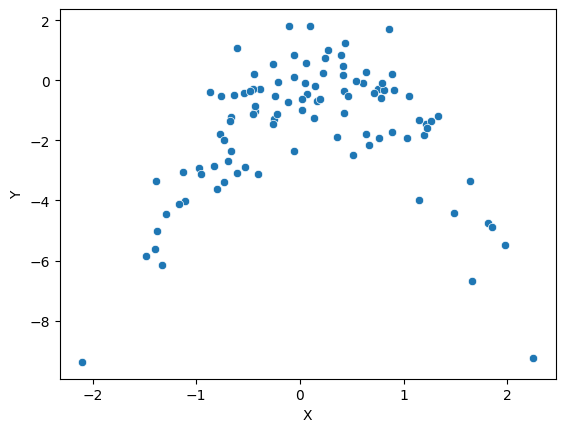

In [11]:
sim_df = pd.DataFrame({"X": x, "Y": y})
print(sns.scatterplot(data=sim_df, x="X", y="Y"))

The scatterplot shows a clear nonlinear (roughly quadratic) relationship: $Y$ tends to increase for moderate negative $X$ and decrease for large positive $X$, consistent with the data-generating model $Y = X - 2X^2 + \varepsilon$. The points are dispersed around this curve due to the added random noise term.

**(c)** Construct 5 folds using `sklearn.model_selection.KFold`, and specify `random_state=3`. Using these folds, compute the cross-validation errors that result from fitting the following four models using least squares. Use the same five folds for all four models.

i. $Y = \beta_0 + \beta_1 X + \epsilon$

ii. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \epsilon$

iii. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon$

iv. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \beta_4 X^4 + \epsilon$

For each fold and each model, report the mean-squared error. Which of the models had the smallest average error? Is this what you expected? Explain your answer.

In [12]:
# 5-fold CV for polynomial least-squares models of degree 1-4
kf = KFold(n_splits = 5, shuffle = True, random_state=3)
degrees = [1,2,3,4]

fold_mse = {d: [] for d in degrees} # dict comprehension

for train_idx, test_idx in kf.split(x): 
    x_train, x_test = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    for d in degrees: 
        # design matrix construction
        X_train = np.column_stack([x_train**k for k in range(1, d + 1)])
        X_test = np.column_stack([x_test**k for k in range(1, d + 1)])

        model = LinearRegression()
        model.fit(X_train, y_train) 
        y_pred = model.predict(X_test)

        fold_mse[d].append(mean_squared_error(y_test, y_pred))
    
errors_df = pd.DataFrame(
    {f"Fold{i+1}": [fold_mse[d][i] for d in degrees] for i in range(5)},
    index=degrees,
)
errors_df["Mean"] = errors_df.mean(axis=1)

errors_df


,Fold1,Fold2,Fold3,Fold4,Fold5,Mean
1,7.956358,3.689411,2.674430,5.298672,4.471893,4.818153
2,0.997101,0.881280,1.228865,2.010389,0.969729,1.217473
3,1.087624,0.895731,1.177539,2.249192,0.966095,1.275236
4,1.065018,0.913249,1.231778,2.293968,0.966019,1.294006


**Smallest average error:** Model 2 (the quadratic model) has the smallest mean CV MSE.

**Is this expected?** Yes. The data were generated from a quadratic relationship,
$Y = X - 2X^2 + \varepsilon$, so degree 2 matches the true signal. Degree 1 underfits (high bias), while degrees 3–4 add unnecessary flexibility that can fit noise (slightly higher variance), so their CV error is typically not smaller on average.

In [13]:
# Test assertions
assert errors_df.shape == (4, 6), f"Expected shape (4, 6), got {errors_df.shape}"
assert errors_df["Mean"].idxmin() == 2, "Model 2 should have the lowest mean error"
print("All tests passed!")

All tests passed!


---

**Problem 4:** LOOCV and Random Seeds

Consider estimating log odds using logistic regression with ridge penalties, setting the regularization strength via LOOCV. True or false: the result will depend on a random seed that we use as part of the LOOCV process. Explain your answer.

**False** (in the usual LOOCV setup).

In **LOOCV**, the data splits are deterministic: each fit leaves out exactly one observation, so there is no random fold assignment and hence no reason for a **random seed** to affect which models are fit or which errors are computed.

The only time a seed could matter is if something else in the pipeline is stochastic (e.g., a randomized optimization algorithm, random tie-breaking, shuffling inside the solver, etc.). But for standard ridge-penalized logistic regression with a deterministic solver and fixed data preprocessing, LOOCV results do **not** depend on a random seed.

---

**Problem 5 (ISLP Ch 5, Exercise 9):** Boston Housing Data Analysis

We will now consider the Boston housing data set, which contains information about housing in the Boston area collected in the 1970s. The target variable `medv` represents the median value of owner-occupied homes in $1000s for each census tract.

**(a)** Based on this data set, provide an estimate for the population mean of `medv`. Call this estimate $\hat{\mu}$ and store it in a variable called `mu_hat`.

In [14]:
boston_df = pd.read_csv("./data/boston.csv")
mu_hat = float(boston_df['medv'].mean())
mu_hat

22.532806324110677

In [15]:
# Test assertions
assert isinstance(mu_hat, float), "mu_hat should be a float"
assert 0 < mu_hat < 100, "Mean should be a reasonable housing value"
print("All tests passed!")

All tests passed!


**(b)** Provide an estimate of the standard error of $\hat{\mu}$ and store it in a variable called `se_mu_hat`. Interpret this result.

**Hint:** We can compute the standard error of the sample mean by dividing the sample standard deviation by the square root of the number of observations.

In [16]:
n_boston = boston_df.shape[0]
se_mu_hat = float(boston_df['medv'].std(ddof=1) / np.sqrt(n_boston))
se_mu_hat

0.40886114749753505

`se_mu_hat` is the estimated **standard deviation of** $\hat{\mu}$ (the sample mean) across repeated samples of the same size.  
Interpretation: the population mean `medv` is being estimated with typical sampling error of about **`se_mu_hat`** (in $1000s of dollars).

In [17]:
# Test assertions
assert isinstance(se_mu_hat, float), "se_mu_hat should be a float"
assert se_mu_hat > 0, "Standard error must be positive"
assert se_mu_hat < mu_hat, "Standard error should be smaller than the mean"
print("All tests passed!")

All tests passed!


**(c)** Now estimate the standard error of $\hat{\mu}$ using the bootstrap. Store the result in a variable called `bootstrap_sem`. How does this compare to your answer from (b)?

In [18]:
rng = np.random.default_rng(3)

medv = boston_df['medv'].to_numpy()
# n_boston = boston_df.shape[0]
B = 10_000

# boostrap resample indices; compute mean of eahc boostrap stample
boot_idx = rng.integers(0, n_boston, size=(B, n_boston)) #output shape: (B, n_boston)
boot_means = medv[boot_idx].mean(axis=1)

# estimate of SE(mu_hat) is the standard deviation of the bootstrap means
bootstrap_sem = float(np.std(boot_means, ddof=1))
bootstrap_sem

0.40844680014282964

The bootstrap estimate of the standard error of $\hat{\mu}$ is `bootstrap_sem`, computed as the standard deviation of the mean `medv` across many bootstrap resamples. It is very close to `se_mu_hat` from part (b), which is expected because both methods are estimating the same sampling variability of the sample mean.

In [19]:
# Test assertions
assert isinstance(bootstrap_sem, float), "bootstrap_sem should be a float"
assert bootstrap_sem > 0, "Standard error must be positive"
assert bootstrap_sem < 1, "Bootstrap SE should be reasonable for this dataset"
print("All tests passed!")

All tests passed!


**(d)** Based on your bootstrap estimate from (c), provide a 95% confidence interval for the mean of `medv`. Compare it to the results obtained by using `boston_df['medv'].std()` and the two standard error rule.

**Hint:** You can approximate a 95% confidence interval using the formula $[\hat{\mu} - 2\text{SE}(\hat{\mu}), \hat{\mu} + 2\text{SE}(\hat{\mu})]$.

In [20]:
# Bootstrap-based CI (using bootstrap_sem from part (c))
ci_low = float(mu_hat - 2 * bootstrap_sem)
ci_high = float(mu_hat + 2 * bootstrap_sem)
confidence_interval_bootstrap = (ci_low, ci_high)

# Standard-error CI (using analytic se_mu_hat from part (b))
ci_se_low = float(mu_hat - 2 * se_mu_hat)
ci_se_high = float(mu_hat + 2 * se_mu_hat)
confidence_interval_standard_error = (ci_se_low, ci_se_high)

confidence_interval_bootstrap, confidence_interval_standard_error

((21.715912723825017, 23.349699924396337),
 (21.715084029115605, 23.35052861910575))

Using the “two standard errors” rule, the 95% CI based on the bootstrap SE is **(21.716, 23.350)**, while the analogous CI using the analytic standard error $s/\sqrt{n}$ is **(21.715, 23.351)**. The intervals are extremely close, but the bootstrap interval is **slightly wider** because the bootstrap SE is **slightly larger** here. This small difference is normal and can arise from variability in the bootstrap (finite $B$ resamples and the particular random seed), and because the bootstrap approximates the sampling distribution empirically rather than relying strictly on the formula $s/\sqrt{n}$.

In [21]:
# Test assertions
ci_low, ci_high = confidence_interval_bootstrap
assert ci_low < mu_hat < ci_high, "Mean should be within CI"
ci_se_low, ci_se_high = confidence_interval_standard_error
assert abs(ci_low - ci_se_low) < 0.1, "Bootstrap and standard CI should be similar"
print("All tests passed!")

All tests passed!


**(e)** Based on this data set, provide an estimate, $\hat{m}$, for the median value of `medv` in the population. Store it in a variable called `median_hat`.

In [22]:
median_hat = float(boston_df['medv'].median())
median_hat

21.2

In [23]:
# Test assertions
assert isinstance(median_hat, float), "median_hat should be a float"
assert 0 < median_hat < 100, "Median should be a reasonable housing value"
print("All tests passed!")

All tests passed!


**(f)** We now would like to estimate the standard error of $\hat{m}$. Unfortunately, there is no simple formula for computing the standard error of the median. Instead, estimate the standard error of the median using the bootstrap and store it in a variable called `bootstrap_se_median`. Comment on your findings.

In [24]:
# rng = np.random.default_rng(3)
# medv = boston_df['medv'].to_numpy()
# n_boston = boston_df.shape[0]
# B = 10_000

# boostrap resample indices; compute mean of eahc boostrap stample
boot_idx = rng.integers(0, n_boston, size=(B, n_boston)) #output shape: (B, n_boston)
boot_medians = np.median(medv[boot_idx], axis=1)

bootstrap_se_median = float(np.std(boot_medians, ddof=1))
bootstrap_se_median

0.377306613251133

Using $B=10{,}000$ bootstrap resamples, the estimated standard error of the sample median $\hat{m}$ is **`bootstrap_se_median ≈ 0.378`** (in $1000s of dollars). This means that if we repeatedly sampled Boston census tracts in the same way, the **sample median `medv` would typically vary by about 0.38** around the true population median due to sampling variability. Because this is a bootstrap estimate, the value may change slightly with a different random seed or a different number of resamples, but it should stay close to this number.

In [25]:
# Test assertions
assert isinstance(bootstrap_se_median, float), "bootstrap_se_median should be a float"
assert bootstrap_se_median > 0, "Standard error must be positive"
assert bootstrap_se_median < 1, "Bootstrap SE should be reasonable for this dataset"
print("All tests passed!")

All tests passed!


**(g)** Based on this data set, provide an estimate for the tenth percentile of `medv` in Boston census tracts. Call this quantity $\hat{p}_{0.1}$ and store it in a variable called `percentile_10_hat`.

**Hint:** You can use `np.percentile()`.

In [26]:
percentile_10_hat = float(np.percentile(medv, 10))
percentile_10_hat

12.75

In [27]:
# Test assertions
assert isinstance(percentile_10_hat, int | float), "percentile_10_hat should be numeric"
assert 0 < percentile_10_hat < median_hat, "10th percentile should be less than the median"
print("All tests passed!")

All tests passed!


**(h)** Use the bootstrap to estimate the standard error of $\hat{p}_{0.1}$ and store it in a variable called `bootstrap_se_percentile`. Comment on your findings.

In [28]:
boot_idx = rng.integers(0, n_boston, size=(B, n_boston))
boot_p10 = np.percentile(medv[boot_idx], 10, axis=1)

bootstrap_se_percentile = float(np.std(boot_p10, ddof=1))
bootstrap_se_percentile

0.5003586972188934

Using $B=10{,}000$ bootstrap resamples, the estimated standard error of the 10th percentile $\hat{p}_{0.1}$ is **about 0.503** (in $1000$s of dollars). This means that across repeated samples, the estimated 10th percentile of `medv` would typically fluctuate by roughly **$0.5$k** around the true population 10th percentile due to sampling variability.

This SE is **larger than the bootstrap SE of the median** ($\approx 0.378$), which is expected because a **lower-tail quantile** (like the 10th percentile) is based on fewer effective observations and is therefore **less stable / more variable** than the median.

In [29]:
# Test assertions
assert isinstance(bootstrap_se_percentile, float), "bootstrap_se_percentile should be a float"
assert bootstrap_se_percentile > 0, "Standard error must be positive"
assert bootstrap_se_percentile < 2, "Bootstrap SE should be reasonable for this dataset"
print("All tests passed!")

All tests passed!


---

**Problem 6:** LOOCV for Logistic Regression

In this problem, you will practice computing the LOOCV error for a logistic regression model on the Weekly data set.

**(a)** Fit a logistic regression model that predicts `Direction` using `Lag1` and `Lag2`. Report the misclassification rate on the training data and comment on the result.

In [30]:
weekly_df = pd.read_csv("./data/weekly.csv")

X = weekly_df[["Lag1", "Lag2"]].to_numpy()
y = (weekly_df["Direction"] == "Up").astype(int).to_numpy() # 1=Up, 0=Down

logit = LogisticRegression(max_iter=10_000).fit(X,y)

y_pred = logit.predict(X) # class lables using default 0.5 threshold 
misclassification_rate_full = float(np.mean(y_pred != y))
misclassification_rate_full


0.44536271808999084

The training misclassification rate is **0.4454**. This means the model correctly classifies about **55.46%** of weeks.

This is only a modest improvement over a naive baseline (e.g., always predicting the majority class), suggesting that **`Lag1` and `Lag2` alone have limited predictive power** for `Direction` on the training data.

In [31]:
# Test assertions
assert isinstance(
    misclassification_rate_full, float
), "misclassification_rate_full should be a float"
assert 0 < misclassification_rate_full < 1, "Misclassification rate must be between 0 and 1"
print("All tests passed!")

All tests passed!


**(b)** Fit a logistic regression model that predicts `Direction` using `Lag1` and `Lag2` using all but the first observation. Report the misclassification rate on the full data and comment on the result.

In [32]:
# slice notation for all but first obs 
X_train = X[1:, :]
y_train = y[1:]

# fit model again
logit_minus1 = LogisticRegression(max_iter=10_000)
logit_minus1.fit(X_train, y_train)

y_pred_full_from_minus1 = logit_minus1.predict(X)
misclassification_rate_without_first = float(np.mean(y_pred_full_from_minus1 != y))

misclassification_rate_without_first

0.44352617079889806

In [33]:
# Test assertions
assert isinstance(
    misclassification_rate_without_first, float
), "misclassification_rate_without_first should be a float"
assert (
    0 < misclassification_rate_without_first < 1
), "Misclassification rate must be between 0 and 1"
print("All tests passed!")

All tests passed!


**(c)** Use the model from (b) to predict the direction of the first observation. Was this observation correctly classified?**No**. 

In [34]:
# Problem 6(c): Predict the first observation using the model fit without it

# Predict class (0=Down, 1=Up) for the first observation
first_pred_class = int(logit_minus1.predict(X[[0], :])[0])
first_true_class = int(y[0])

first_observation_correct = bool(first_pred_class == first_true_class)

# Optional: human-readable labels
first_pred_label = "Up" if first_pred_class == 1 else "Down"
first_true_label = "Up" if first_true_class == 1 else "Down"

first_pred_label, first_true_label, first_observation_correct

('Up', 'Down', False)

In [35]:
# Test assertions
assert not first_observation_correct, "First observation should be incorrectly classified"
print("All tests passed!")

All tests passed!


**(d)** Write a for loop from `i = 0` to `i = n-1`, where `n` is the number of observations in the data set, that performs each of the following steps:

i. Fit a logistic regression model using all but the `i`th observation to predict `Direction` using `Lag1` and `Lag2`.

ii. Use this model to predict the direction for the `i`th observation.

iii. Determine whether or not an error was made in predicting the direction for the `i`th observation. If an error was made, then indicate this as a 1, and otherwise indicate it as a 0.

In [36]:
# LOOCV loop (store 1 if error else 0)

n = len(y)
loocv_errors = []

for i in range(n): 
    mask = np.ones(n, dtype=bool) # all start True
    mask[i] = False

    # only keeps rows where mask is True
    X_train_i = X[mask, :]
    y_train_i = y[mask]

    model_i = LogisticRegression(max_iter = 10_000)
    model_i.fit(X_train_i, y_train_i)

    y_pred_i = int(model_i.predict(X[[i], :])[0])
    loocv_errors.append(int(y_pred_i != int(y[i])))

loocv_errors[:10], len(loocv_errors) # checking output

([1, 1, 0, 1, 0, 1, 0, 0, 0, 1], 1089)

In [37]:
# Test assertions
assert len(loocv_errors) == len(y), f"Expected {len(y)} errors, got {len(loocv_errors)}"
assert all(e in [0, 1] for e in loocv_errors), "Errors should be 0 or 1"
print("All tests passed!")

All tests passed!


**(e)** Take the average of the `n` numbers obtained in part (d)(iii) of this problem in order to obtain the LOOCV estimate for the test error. Comment on the results.

In [40]:
loocv_error_rate = float(np.mean(loocv_errors)) # summing True (1) values
loocv_accuracy = float(1 - loocv_error_rate)

loocv_error_rate, loocv_accuracy

(0.44995408631772266, 0.5500459136822773)

The LOOCV misclassification rate is **0.4500** (accuracy **0.5500**), which is very close to—but **slightly higher than**—the training misclassification rate **0.4454**. This small increase is expected because the training error is typically optimistic (evaluated on the same data used for fitting), whereas LOOCV better approximates out-of-sample performance. The closeness of the two rates suggests limited overfitting, but the accuracy remains only modest using `Lag1` and `Lag2`.

In [42]:
# Test assertions
assert isinstance(loocv_error_rate, float), "loocv_error_rate should be a float"
assert 0 < loocv_error_rate < 1, "Error rate must be between 0 and 1"
print("All tests passed!")

All tests passed!
